In [88]:
import os
import pickle
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from pathfinding.core.grid import Grid
from pathfinding.finder.a_star import AStarFinder
from pathfinding.core.diagonal_movement import DiagonalMovement

from RRAM import Representate as rp

In [89]:
# Estado inicial de la simulación reset para las vacantes
ruta_raiz = os.getcwd() + "/Estado_inicial.pdf"
print("Ruta raiz del proyecto:", ruta_raiz)

with open("Init_data/init_state_0.pkl", "rb") as file:
    # Carga el contenido del archivo
    initial_configuration = pickle.load(file)

rp.RepresentateState(initial_configuration, 0.00, ruta_raiz)


Ruta raiz del proyecto: c:\Users\Usuario\Documents\GitHub\RRAM_Simulation/Estado_inicial.pdf


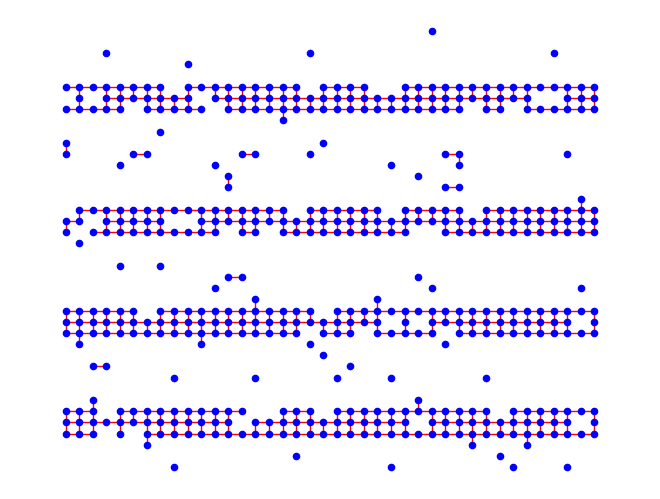

In [90]:
# Crear grafo no dirigido
G = nx.Graph()

grid = np.array(initial_configuration)
H, W = grid.shape
dirs = [(1, 0), (0, 1), (-1, 0), (0, -1)]  # movimientos ortogonales

for i in range(H):
    for j in range(W):
        if grid[i, j] == 1:  # solo celdas caminables
            G.add_node((i, j))  # agregamos el nodo
            for di, dj in dirs:
                ni, nj = i + di, j + dj
                if 0 <= ni < H and 0 <= nj < W and grid[ni, nj] == 1:
                    G.add_edge((i, j), (ni, nj))  # agregamos arista bidireccional
                    
pos = {(i, j): (j, i) for i, j in G.nodes()}  # -i para invertir el eje y si quiere
nx.draw(G, pos=pos, node_size=20, node_color="blue", edge_color="red")
plt.show()

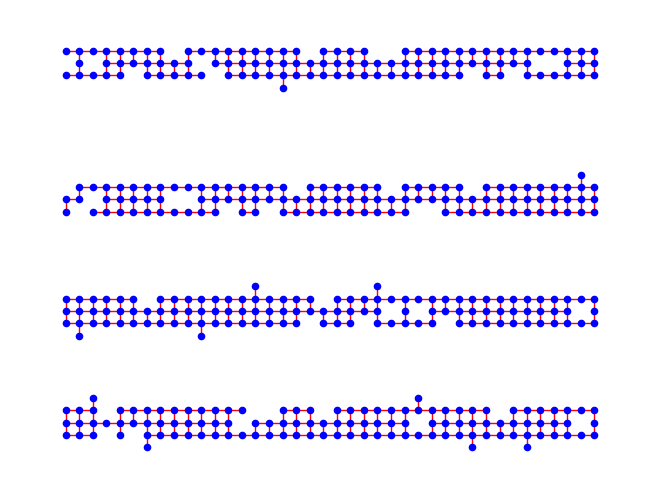

Número de componentes conectados: 4


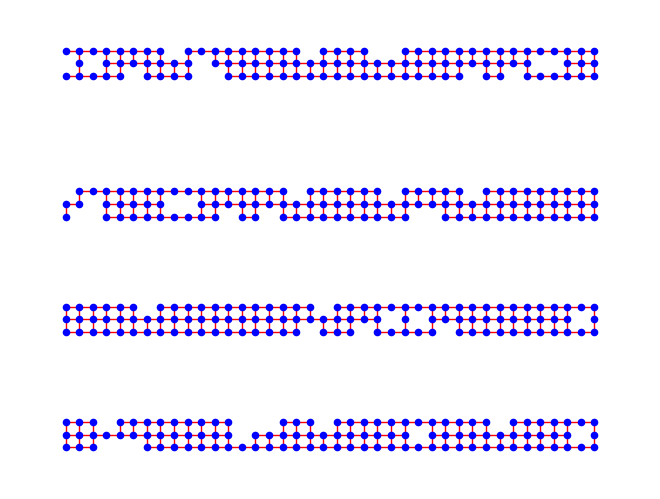

In [ ]:
# ELimino los nodos que no tienen aristas
G.remove_nodes_from(list(nx.isolates(G)))

componentes = list(nx.connected_components(G))
validos = [c for c in componentes if len(c) > 20]
nodos_finales = set().union(*validos)
G = G.subgraph(nodos_finales).copy()

print("Número de componentes conectados:", len(validos))

# Nodos con grado 1 (hojas), excluyendo primera y última columna
leaf_nodes = [n for n, d in G.degree() if d == 1 and n[1] not in (0, W - 1)]
G.remove_nodes_from(leaf_nodes)

nx.draw(G, pos=pos, node_size=20, node_color="blue", edge_color="red")

plt.show()

In [92]:
# Crear matriz vacía de ceros
clean_grid = np.zeros((H, W), dtype=int)

# Poner 1 en las posiciones de los nodos que siguen en G
for i, j in G.nodes():
    clean_grid[i, j] = 1

rp.RepresentateState(clean_grid, 0.00, os.getcwd() + "/Estado_inicial_filtro.pdf")

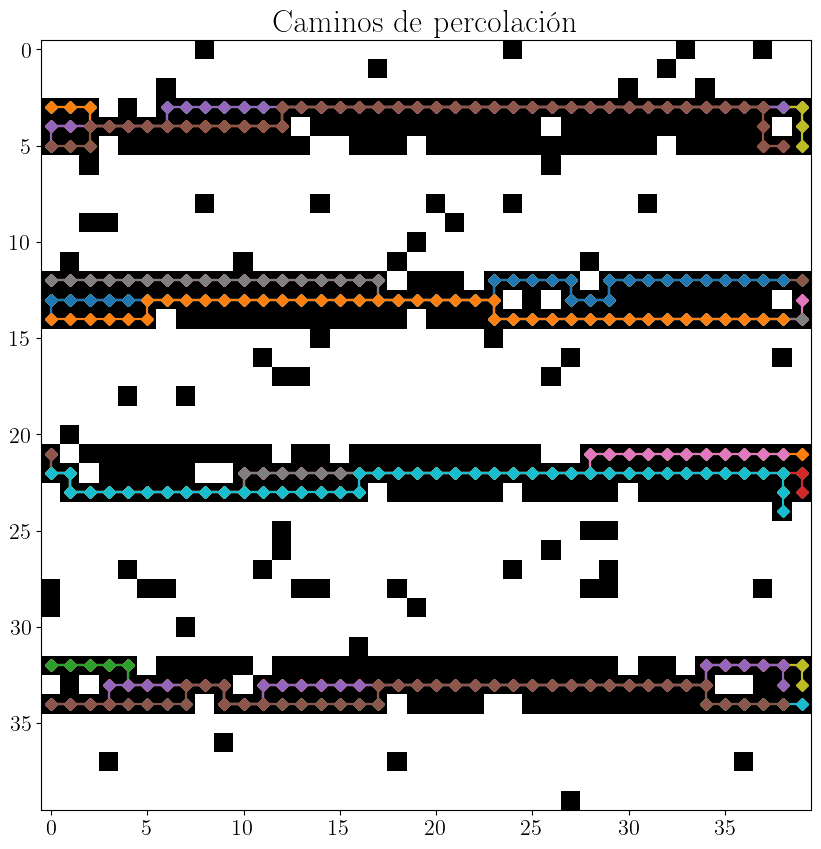

In [93]:
def Obtenin_Paths(configuration_matrix: np.ndarray) -> list:
    """
    Finds all possible paths from the first column to the last column in a given configuration matrix using the A* algorithm.
    Args:
        configuration_matrix (np.ndarray): A 2D numpy array representing the configuration matrix where '1' indicates a traversable cell and '0' indicates an obstacle.
    Returns:
        list: A list of numpy arrays, each containing tuples representing the coordinates of the path from the first column to the last column.
    """
    # obtengo las dimensiones de la matriz
    _, Ejey = configuration_matrix.shape

    # Lista para almacenar todos los caminos
    all_paths_list = []

    # Compruebo si hay trampas en la primera y última columna
    if 1 in configuration_matrix[:, 0] and 1 in configuration_matrix[:, -1]:
        # obtengo las posiciones de los 1 en la primera columna
        start = np.where(configuration_matrix[:, 0] == 1)[0]

        # Creo la lista de nodos de inicio sabiendo que todos los nodos de inicio están en la primera columna
        start = [(i, 0) for i in start]

        # obtengo las posiciones de los 1 en la última columna
        end = np.where(configuration_matrix[:, -1] == 1)[0]

        for k in [1, 2]:
            # obtengo las posiciones de los 1 en la última columna
            end = np.where(configuration_matrix[:, -k] == 1)[0]

            # Creo la lista de nodos de fin sabiendo que todos los nodos de fin están en la última columna en forma de grid node
            end = [(i, Ejey - k) for i in end]

            # Recorro los nodos de inicio y fin para ver si hay camino
            finder = AStarFinder(diagonal_movement=DiagonalMovement.never)

            for i in start:
                for j in end:
                    grid = Grid(matrix=configuration_matrix)

                    node_start = grid.node(i[1], i[0])
                    node_end = grid.node(j[1], j[0])

                    path, runs = finder.find_path(node_start, node_end, grid)
                    if len(path) > 0:
                        # Convert path to a numpy array of tuples
                        path_tuples = np.array([(node.x, node.y) for node in path])
                        all_paths_list.append(path_tuples)

    return all_paths_list

def plot_percolation_paths(configuration_matrix: np.ndarray, paths: list):
    plt.figure(figsize=(10, 10))
    plt.imshow(configuration_matrix, cmap="Greys", interpolation="none")

    for path in paths:
        path = np.array(path)
        plt.plot(path[:, 0], path[:, 1], marker="D")

    plt.title("Caminos de percolación")
    plt.show()


# Uso de la función con la matriz de configuración inicial y los caminos de percolación

# Uso de la función con la matriz de configuración inicial
percolation_paths = Obtenin_Paths(initial_configuration)
plot_percolation_paths(initial_configuration, percolation_paths)


In [94]:
def generate_resitence_matrix(config_matrix: np.ndarray, min_size: int = 10, plot_resmatrix: bool = False) -> np.ndarray:
    
    # Preparar el grafo no dirigido (A-B es igual que B-A)
    G = nx.Graph()
    grid = np.array(config_matrix)
    H, W = grid.shape
    dirs = [(1, 0), (0, 1), (-1, 0), (0, -1)]  # movimientos ortogonales

    # Creo el grid de nodos a partir de la matriz de configuracion
    for i in range(H):
        for j in range(W):
            if grid[i, j] == 1:  # solo celdas caminables
                G.add_node((i, j))  # agregamos el nodo
                for di, dj in dirs:
                    ni, nj = i + di, j + dj
                    if 0 <= ni < H and 0 <= nj < W and grid[ni, nj] == 1:
                        G.add_edge((i, j), (ni, nj))  # agregamos arista bidireccional

    # Elimino los nodos que no tienen aristas
    G.remove_nodes_from(list(nx.isolates(G)))

    # ELimino componentes pequeños sueltos
    componentes = list(nx.connected_components(G))
    validos = [c for c in componentes if len(c) > min_size]
    nodos_finales = set().union(*validos)
    G = G.subgraph(nodos_finales).copy()

    print("Número de componentes conectados:", len(validos))

    # Elimino los Nodos con grado 1 (hojas), excluyendo primera y última columna
    leaf_nodes = [n for n, d in G.degree() if d == 1 and n[1] not in (0, W - 1)]
    G.remove_nodes_from(leaf_nodes)

    # Crear matriz vacía de ceros para la matriz resistencia
    resistance_matriz = np.zeros((H, W), dtype=int)

    # Poner 1 en las posiciones de los nodos que siguen en G
    for i, j in G.nodes():
        resistance_matriz[i, j] = 1
        
    if plot_resmatrix:
        rp.RepresentateState(resistance_matriz, 0.00, os.getcwd() + "/Matriz_resistencia.pdf")
        
    return resistance_matriz
